<a href="https://colab.research.google.com/github/aiswaryasds25-lab/Project2_StudentPerformance_Prediction_and_Earlyintervention/blob/decision-tree-feature-importance/Added%20Decision%20Tree%20and%20feature%20importance%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Decision Tree Model Training**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


Load Dataset

In [ ]:
df = pd.read_csv("student-mat.csv", sep=';')

Features and Target

In [ ]:
def preprocess_df(dataframe):
    dataframe['result'] = (dataframe['G3'] >= 10).astype(int)

    # Drop the original grade columns as 'result' is derived from G3
    dataframe = dataframe.drop(['G1', 'G2', 'G3'], axis=1)

    # Identify categorical columns for one-hot encoding
    categorical_cols = dataframe.select_dtypes(include='object').columns

    # Apply one-hot encoding
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=True)

    return dataframe

processed_df = preprocess_df(df)

X = processed_df.drop("result", axis=1)
y = processed_df["result"]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Create Model

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

Train Model

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Model Evaluation**

Added Decision Tree evaluation metrics

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Predictions

In [14]:
y_pred = dt.predict(X_test)

Accuracy

In [15]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.7341772151898734


Classification Report

In [16]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.30      0.43        27
           1       0.72      0.96      0.83        52

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79



Confusion Matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 8 19]
 [ 2 50]]


**Confusion Matrix Visualization**

Added confusion matrix visualization

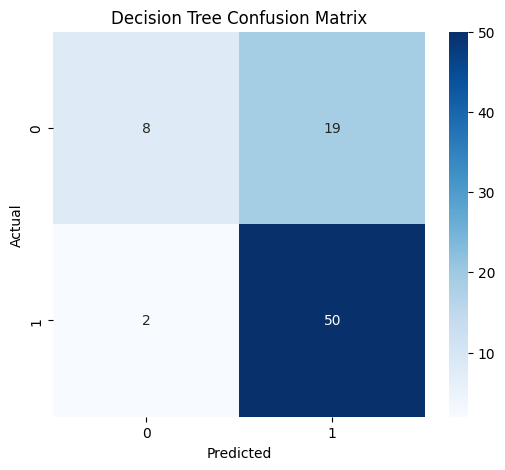

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()